In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\JANHAVI\Desktop\Data_Analyst_Project\sales_dataset_50k.csv")

In [3]:
print(df.head())

   Order_ID  Order_Date Region         Category  Product    Sales  Quantity  \
0    100000  2024-09-06  North         Clothing    Shoes   383.20         5   
1    100001  2024-10-25   West        Furniture     Desk   929.31         3   
2    100002  2024-01-21  South         Clothing    Jeans  1940.42         5   
3    100003  2024-07-14  North  Office Supplies  Stapler  1242.61         5   
4    100004  2023-07-09   East         Clothing   Jacket   112.40         2   

   Profit  
0   93.85  
1  124.00  
2  500.84  
3  252.14  
4   32.98  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    50000 non-null  int64  
 1   Order_Date  50000 non-null  object 
 2   Region      50000 non-null  object 
 3   Category    50000 non-null  object 
 4   Product     50000 non-null  object 
 5   Sales       50000 non-null  float64
 6   Quantity    50000 non-null  int64  
 7   Profit      50000 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 3.1+ MB
None


In [5]:
# Check missing values
print(df.isnull().sum())

Order_ID      0
Order_Date    0
Region        0
Category      0
Product       0
Sales         0
Quantity      0
Profit        0
dtype: int64


In [6]:
# Convert date column
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [7]:
# Remove duplicates
df = df.drop_duplicates()


In [8]:
# Create new features
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year

In [9]:
# Basic statistics
print(df.describe())

            Order_ID                  Order_Date         Sales      Quantity  \
count   50000.000000                       50000  50000.000000  50000.000000   
mean   124999.500000  2023-12-31 11:55:25.248000   1012.395875      2.999180   
min    100000.000000         2023-01-01 00:00:00     20.000000      1.000000   
25%    112499.750000         2023-07-01 00:00:00    510.905000      2.000000   
50%    124999.500000         2023-12-31 00:00:00   1013.670000      3.000000   
75%    137499.250000         2024-07-01 00:00:00   1508.135000      4.000000   
max    149999.000000         2024-12-30 00:00:00   1999.940000      5.000000   
std     14433.901067                         NaN    573.115612      1.415252   

             Profit        Month          Year  
count  50000.000000  50000.00000  50000.000000  
mean     176.545609      6.51542   2023.499600  
min        1.240000      1.00000   2023.000000  
25%       72.110000      4.00000   2023.000000  
50%      145.680000      7.00000  

# Business Analysis

# Category Performance

In [10]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Office Supplies    12838059.49
Electronics        12695095.54
Clothing           12646324.86
Furniture          12440313.86
Name: Sales, dtype: float64


# Region Profit Analysis

In [11]:
region_profit = df.groupby('Region')['Profit'].sum()

print(region_profit)

Region
East     2181087.43
North    2229510.34
South    2217126.38
West     2199556.29
Name: Profit, dtype: float64


# Visualization

# Sales By Category

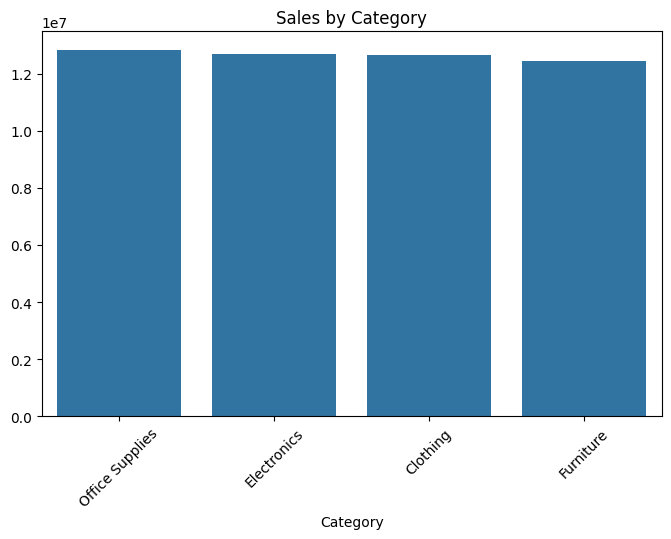

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Sales by Category")
plt.xticks(rotation=45)

plt.show()

# Monthly Sales Trend

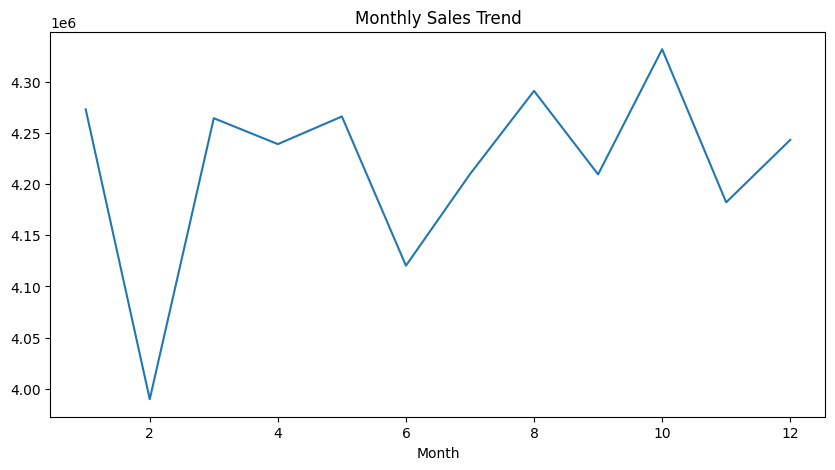

In [13]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.show()

# Machine Learning – Sales Forecasting

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


In [15]:
# Features
X = df[['Month', 'Quantity']]
y = df['Sales']


In [16]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [17]:
# Model
model = LinearRegression()


In [18]:
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# Prediction
predictions = model.predict(X_test)

In [20]:
# Error
error = mean_absolute_error(y_test, predictions)

In [21]:
print("Model Error:", error)

Model Error: 500.2757188683003
